In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# NewsAPI Key (free tier: 100 requests/day)
# Get your own at: https://newsapi.org/
api_key = '4dbc17e007ab436fb66416009dfb59a8'  # Demo key

print("✅ Libraries loaded!")
print("📰 PROJECT: Live News Headlines Scraper")
print(f"🔑 API Key: {api_key[:10]}...")

✅ Libraries loaded!
📰 PROJECT: Live News Headlines Scraper
🔑 API Key: 4dbc17e007...


In [13]:
# Get top headlines from India

url = f'https://newsapi.org/v2/everything?q={topic}&language=en&sortBy=publishedAt&apiKey={api_key}'


response = requests.get(url)
data = response.json()

print(f"✅ Status: {data['status']}")
print(f"📊 Total results: {data['totalResults']}")

# Preview first article
print("\n📰 SAMPLE ARTICLE:")
print(data['articles'][0])

✅ Status: ok
📊 Total results: 14129

📰 SAMPLE ARTICLE:
{'source': {'id': None, 'name': 'The Week Magazine'}, 'author': 'theweekonlineeditorsuk@futurenet.com (Marc Shoffman, The Week UK) , Marc Shoffman, The Week UK', 'title': 'Five scams impacting older people and how to fight back', 'description': 'Fraudsters are evolving and older people are becoming increasingly vulnerable', 'url': 'https://theweek.com/personal-finance/five-scams-impacting-older-people-and-how-to-fight-back', 'urlToImage': 'https://cdn.mos.cms.futurecdn.net/cWMpeFeXkzjeXfZZnep2So-2000-80.jpg', 'publishedAt': '2026-05-13T12:41:34Z', 'content': 'Older people are becoming increasingly vulnerable to scams, and the latest target appears to be inheritance tax.\r\nFrom April 2027, pensions are to be used in inheritance calculations, but criminals a… [+4179 chars]'}


In [14]:
articles_data = []

for article in data['articles']:
    articles_data.append({
        'title': article['title'],
        'source': article['source']['name'],
        'author': article.get('author', 'Unknown'),  # .get() avoids errors if missing
        'description': article.get('description', ''),
        'url': article['url'],
        'published_at': article['publishedAt']
    })

# Create DataFrame
df_news = pd.DataFrame(articles_data)

print(f"✅ Collected {len(df_news)} articles!")
print("\n📰 LATEST HEADLINES:")
print(df_news[['title', 'source']].head(10))

✅ Collected 99 articles!

📰 LATEST HEADLINES:
                                               title              source
0  Five scams impacting older people and how to f...   The Week Magazine
1  Tower Semi forecasts upbeat quarterly revenue,...  The Times of India
2  Wall Street Mixed Early And Oil Prices Steady ...            HuffPost
3         FCC Approves Echostar ATT and SpaceX Deals     Next Big Future
4  "Incredibly Unpopular Technology": Astra Taylo...      Democracy Now!
5  Real-Time Intoxication Detection Platforms Tar...      Financial Post
6  Universal Is Spending 10 Million Dollars to Bu...    Inside the Magic
7  Exclusive: AirOps targets emerging AI search m...   SiliconANGLE News
8  Utah’s Hyperscale Data Center: A Betrayal of D...        Shtfplan.com
9  For 250 years, America didn’t just invent the ...             Fortune


In [18]:
# Get news for different categories

categories = ['business', 'technology', 'sports', 'entertainment', 'health']

all_news = []

for category in categories:
    print(f"\n📡 Fetching {category.upper()} news...")
    
    url = f'https://newsapi.org/v2/everything?q={category}&language=en&sortBy=publishedAt&apiKey={api_key}'

    response = requests.get(url)
    data = response.json()
    
    for article in data.get('articles', [])[:5]:  # Top 5 from each category
        all_news.append({
            'category': category,
            'title': article['title'],
            'source': article['source']['name'],
            'url': article['url'],
            'published_at': article['publishedAt']
        })

# Create comprehensive DataFrame
df_all_news = pd.DataFrame(all_news)

print(f"\n✅ Collected {len(df_all_news)} articles across {len(categories)} categories!")
print(df_all_news.head())

# Save
df_all_news.to_csv('india_news_headlines.csv', index=False)
print("\n💾 Saved to 'india_news_headlines.csv'")


📡 Fetching BUSINESS news...

📡 Fetching TECHNOLOGY news...

📡 Fetching SPORTS news...

📡 Fetching ENTERTAINMENT news...

📡 Fetching HEALTH news...

✅ Collected 25 articles across 5 categories!
   category                                              title         source  \
0  business  Red Banyan Ranked No. 1 Boutique Crisis Commun...  GlobeNewswire   
1  business  Tube Investments Q4 revenue up 20%; nod for lo...   BusinessLine   
2  business  Hyperscalers' AI buildout will require massive...           CNBC   
3  business                                     pospilot 1.0.2       Pypi.org   
4  business  Digital Turbine and Databricks Partner to Acce...     PRNewswire   

                                                 url          published_at  
0  https://www.globenewswire.com/news-release/202...  2026-05-13T12:51:00Z  
1  https://www.thehindubusinessline.com/news/tube...  2026-05-13T12:50:24Z  
2  https://www.cnbc.com/2026/05/13/hyperscalers-a...  2026-05-13T12:50:10Z  
3          

In [19]:
print("📰 NEWS BY CATEGORY:")
print(df_all_news['category'].value_counts())

print("\n📡 TOP NEWS SOURCES:")
print(df_all_news['source'].value_counts().head(10))

📰 NEWS BY CATEGORY:
category
business         5
technology       5
sports           5
entertainment    5
health           5
Name: count, dtype: int64

📡 TOP NEWS SOURCES:
source
The Conversation Africa    5
PRNewswire                 4
The Times of India         3
CNBC                       2
Pypi.org                   2
GlobeNewswire              1
BusinessLine               1
The Hollywood Gossip       1
Rediff.com                 1
Www.gov.uk                 1
Name: count, dtype: int64


In [27]:
# Simple keyword-based sentiment (positive vs negative words)

positive_keywords = ['success', 'win', 'growth', 'record', 'boost', 'surge', 
                     'improve', 'gain', 'rise', 'best', 'top']

negative_keywords = ['crash', 'fail', 'drop', 'loss', 'crisis', 'scandal',
                     'decline', 'worst', 'concern', 'risk', 'threat']

def simple_sentiment(text):
    """Analyze sentiment based on keywords"""
    if pd.isna(text):
        return 'neutral'
    
    text_lower = text.lower()
    
    pos_count = sum(1 for word in positive_keywords if word in text_lower)
    neg_count = sum(1 for word in negative_keywords if word in text_lower)
    
    if pos_count > neg_count:
        return 'positive'
    elif neg_count > pos_count:
        return 'negative'
    else:
        return 'neutral'

# Apply sentiment analysis
df_all_news['sentiment'] = df_all_news['title'].apply(simple_sentiment)

print("📊 SENTIMENT BREAKDOWN:")
print(df_all_news['sentiment'].value_counts())

print("\n🙂 POSITIVE NEWS:")
print(df_all_news[df_all_news['sentiment'] == 'positive']['title'].head(3).tolist())

print("\n😞 NEGATIVE NEWS:")
print(df_all_news[df_all_news['sentiment'] == 'negative']['title'].head(3).tolist())

📊 SENTIMENT BREAKDOWN:
sentiment
neutral     17
positive     5
negative     3
Name: count, dtype: int64

🙂 POSITIVE NEWS:
['Tube Investments Q4 revenue up 20%; nod for long-term borrowing of up to ₹350 crore', 'How tarot readers are using AI – and what it says about our growing reliance on chatbots for emotional support and advice', 'Water Sports Foundation Shares Eight Top Boating Tips for a Fun Memorial Day Weekend']

😞 NEGATIVE NEWS:
['Red Banyan Ranked No. 1 Boutique Crisis Communications Firm in the United States', 'World Sevens Football: A bold step forward or a risk to the women’s game?', 'Detroit’s water affordability crisis is tied to the uneven distribution of stormwater management costs – a fraught history explains why']


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4588\2011878831.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.values, y=category_counts.index, palette='rocket', ax=axes[0, 0])
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4588\2011878831.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_sources.values, y=top_sources.index, palette='viridis', ax=axes[0, 1])
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4588\2011878831.py:36: UserWarning: Glyph 128240 (\N{NEWSPAPER}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_4588\2011878831.py:36: UserWarning: Glyph 127470 (\N{REGIONAL INDICATOR SYMBOL LETTER I}) missing from font(s)

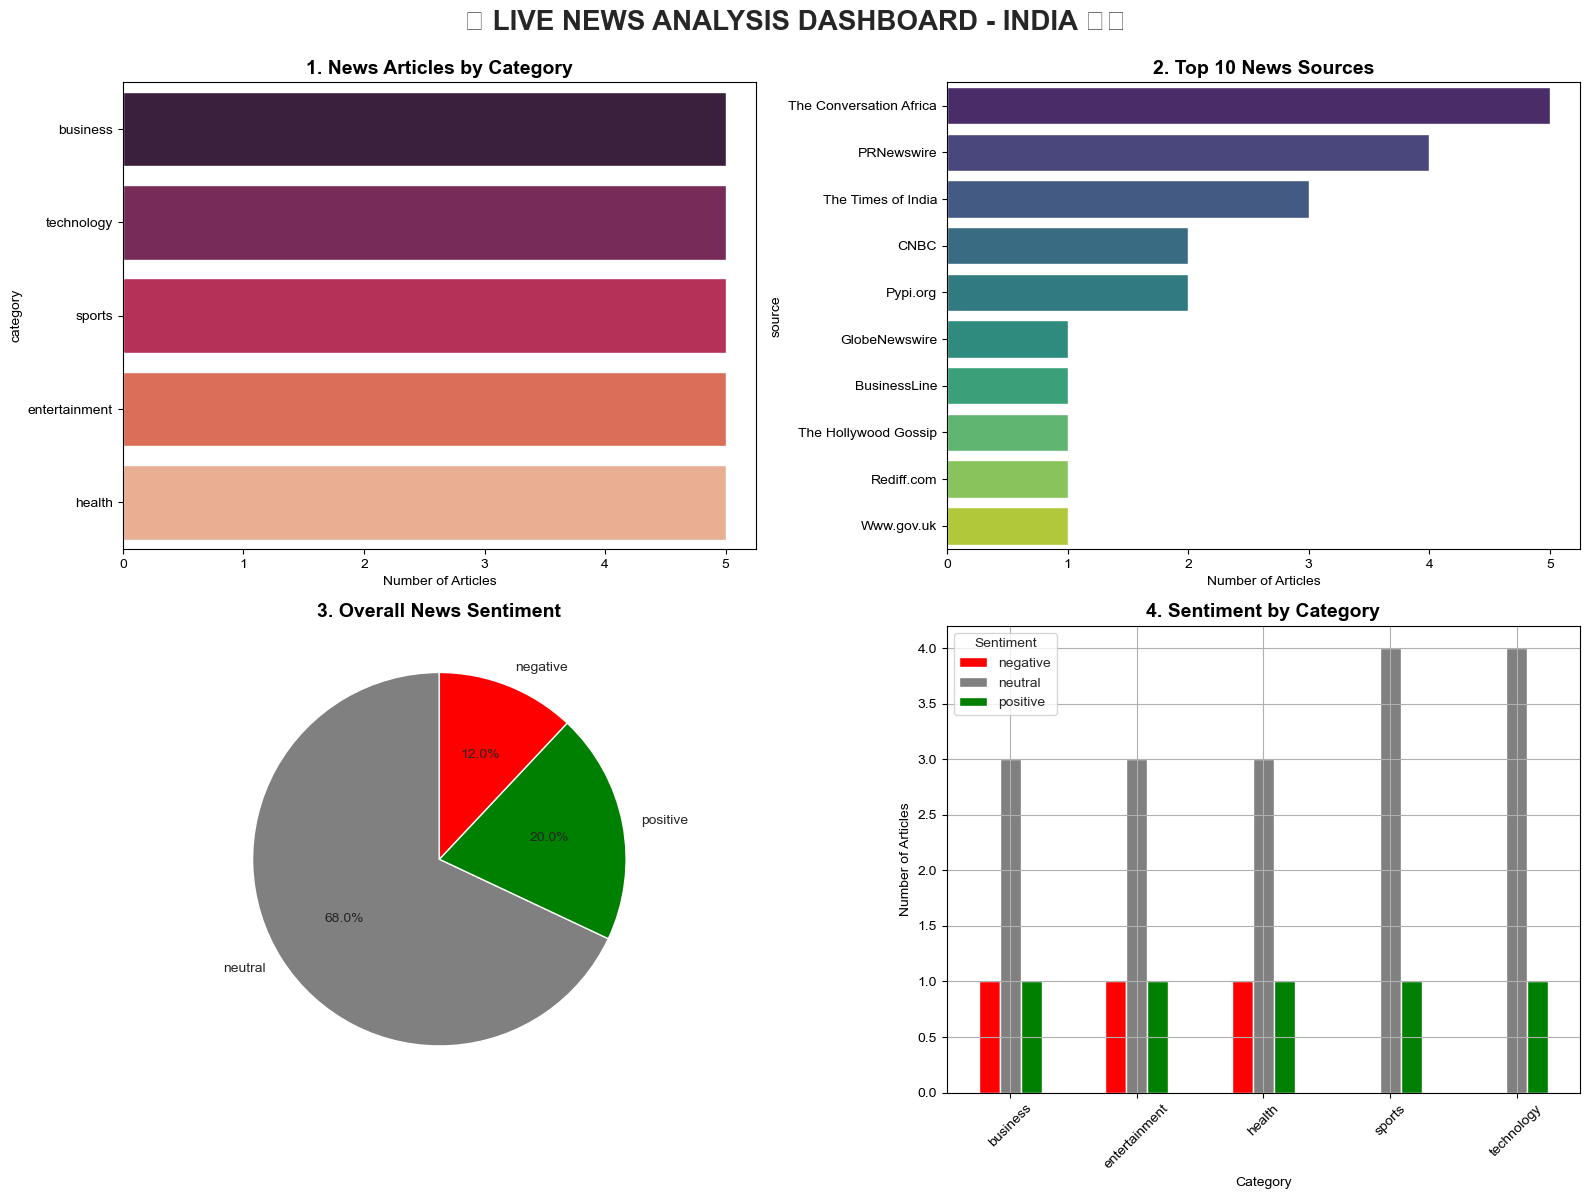

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.set_style('whitegrid')

# Chart 1: Articles by Category
category_counts = df_all_news['category'].value_counts()
sns.barplot(x=category_counts.values, y=category_counts.index, palette='rocket', ax=axes[0, 0])
axes[0, 0].set_title('1. News Articles by Category', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Number of Articles')

# Chart 2: Top News Sources
top_sources = df_all_news['source'].value_counts().head(10)
sns.barplot(x=top_sources.values, y=top_sources.index, palette='viridis', ax=axes[0, 1])
axes[0, 1].set_title('2. Top 10 News Sources', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Number of Articles')

# Chart 3: Sentiment Distribution
sentiment_counts = df_all_news['sentiment'].value_counts()
colors = ['green' if s == 'positive' else 'red' if s == 'negative' else 'gray' 
          for s in sentiment_counts.index]
axes[1, 0].pie(sentiment_counts.values, labels=sentiment_counts.index, 
               autopct='%1.1f%%', colors=colors, startangle=90)
axes[1, 0].set_title('3. Overall News Sentiment', fontsize=14, fontweight='bold')

# Chart 4: Sentiment by Category
sentiment_by_category = df_all_news.groupby(['category', 'sentiment']).size().unstack(fill_value=0)
sentiment_by_category.plot(kind='bar', ax=axes[1, 1], color=['red', 'gray', 'green'])
axes[1, 1].set_title('4. Sentiment by Category', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Category')
axes[1, 1].set_ylabel('Number of Articles')
axes[1, 1].legend(title='Sentiment')
axes[1, 1].tick_params(axis='x', rotation=45)

fig.suptitle('📰 LIVE NEWS ANALYSIS DASHBOARD - INDIA 🇮🇳', 
             fontsize=20, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

In [28]:
# Search news about a specific topic

topic = 'artificial intelligence'  # Change this to any topic!

url = f'https://newsapi.org/v2/everything?q={topic}&language=en&sortBy=publishedAt&apiKey={api_key}'

response = requests.get(url)
data = response.json()

print(f"🔍 Searching for: '{topic}'")
print(f"📊 Found {data['totalResults']} articles!")

print(f"\n📰 TOP 10 ARTICLES ABOUT '{topic.upper()}':")
for idx, article in enumerate(data['articles'][:10], 1):
    print(f"\n{idx}. {article['title']}")
    print(f"   Source: {article['source']['name']}")
    print(f"   Published: {article['publishedAt'][:10]}")

🔍 Searching for: 'artificial intelligence'
📊 Found 14149 articles!

📰 TOP 10 ARTICLES ABOUT 'ARTIFICIAL INTELLIGENCE':

1. Morgan Properties Appoints Devang Patel as Head of Technology
   Source: Financial Post
   Published: 2026-05-13

2. SEALSQ Positioned for Leadership in Orbital Quantum Security and Space-Based Data Centers with Post-Quantum Semiconductor Technology
   Source: GlobeNewswire
   Published: 2026-05-13

3. Smart glasses are 'an invasion of privacy' - Meta's are selling better than ever
   Source: BBC News
   Published: 2026-05-13

4. Kai Earns Gold APA Labs Digital Badge for Conversational AI Mental Health Platform
   Source: PRNewswire
   Published: 2026-05-13

5. Whys Is Micron Tech Stock Trending On Trump's China Visit?
   Source: Yahoo Entertainment
   Published: 2026-05-13

6. Seismic “check-up” for Greece’s buildings: Vulnerable areas and aging structures — What an NTUA Professor says
   Source: Protothema.gr
   Published: 2026-05-13

7. AI In Operations: How Com

Try different topics:

"cryptocurrency"
"climate change"
"space exploration"
"IPL 2026"
"bollywood"

